In [1]:
# %% [markdown]
# # RF and XGBoost Benchmark for Irrigation Classification

# %% Imports
import os
import glob
import numpy as np
import rasterio
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    accuracy_score, jaccard_score, f1_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import joblib
import json

# XGBoost
from xgboost import XGBClassifier

In [2]:
# %% Configuration
base_dir = '/discover/nobackup/ejalilva/data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-irrigation-classificaction/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/'
TRAIN_DIR = os.path.join(base_dir,'training_chips')
VAL_DIR = os.path.join(base_dir,'validation_chips')
OUTPUT_DIR = 'rf_outputs'

CLASS_NAMES = ["Water", "non-ag", "Irrigated", "Rainfed"]

os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(42)

In [3]:
# %% Find training chips
train_images = sorted(glob.glob(os.path.join(TRAIN_DIR, '*_merged.tif')))
print(f"Found {len(train_images)} training chips")

# %% Load ONE chip to verify structure
test_img_path = train_images[0]
test_mask_path = test_img_path.replace('_merged.tif', '.mask.tif')

with rasterio.open(test_img_path) as src:
    test_img = src.read()
    print(f"Image shape: {test_img.shape}")  # (18, H, W)

with rasterio.open(test_mask_path) as src:
    test_mask = src.read(1)
    print(f"Mask shape: {test_mask.shape}")
    print(f"Unique values: {np.unique(test_mask)}")

Found 3058 training chips
Image shape: (18, 224, 224)
Mask shape: (224, 224)
Unique values: [0 1 2 3]


In [4]:
# %% Load TRAINING data
all_X_train, all_y_train = [], []

for img_path in tqdm(train_images, desc="Loading training"):
    mask_path = img_path.replace('_merged.tif', '.mask.tif')
    if not os.path.exists(mask_path):
        continue
    
    with rasterio.open(img_path) as src:
        img = src.read()  # (18, H, W)
    with rasterio.open(mask_path) as src:
        mask = src.read(1)  # (H, W)
    
    X = img.reshape(img.shape[0], -1).T  # (H*W, 18)
    y = mask.flatten()
    
    valid = (y >= 0) & (y < 4)
    all_X_train.append(X[valid])
    all_y_train.append(y[valid])

X_train = np.concatenate(all_X_train)
y_train = np.concatenate(all_y_train)
print(f"Training: {X_train.shape[0]:,} pixels, {X_train.shape[1]} features")

Loading training: 100%|██████████| 3058/3058 [02:20<00:00, 21.81it/s]


Training: 153,438,208 pixels, 18 features


In [5]:
# %% Load VALIDATION data
val_images = sorted(glob.glob(os.path.join(VAL_DIR, '*_merged.tif')))
print(f"Found {len(val_images)} validation chips")

all_X_val, all_y_val = [], []

for img_path in tqdm(val_images, desc="Loading validation"):
    mask_path = img_path.replace('_merged.tif', '.mask.tif')
    if not os.path.exists(mask_path):
        continue
    
    with rasterio.open(img_path) as src:
        img = src.read()
    with rasterio.open(mask_path) as src:
        mask = src.read(1)
    
    X = img.reshape(img.shape[0], -1).T
    y = mask.flatten()
    
    valid = (y >= 0) & (y < 4)
    all_X_val.append(X[valid])
    all_y_val.append(y[valid])

X_val = np.concatenate(all_X_val)
y_val = np.concatenate(all_y_val)
print(f"Validation: {X_val.shape[0]:,} pixels")

Found 766 validation chips


Loading validation: 100%|██████████| 766/766 [00:36<00:00, 20.89it/s]


Validation: 38,434,816 pixels


In [6]:
# %% (Optional) Subsample if too large
MAX_PIXELS = 5_000_000

if len(y_train) > MAX_PIXELS:
    idx = np.random.choice(len(y_train), MAX_PIXELS, replace=False)
    X_train, y_train = X_train[idx], y_train[idx]
    print(f"Subsampled to {MAX_PIXELS:,}")

# %% Class distribution
unique, counts = np.unique(y_train, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  {CLASS_NAMES[int(c)]}: {n:,} ({100*n/len(y_train):.1f}%)")

Subsampled to 5,000,000
  Water: 551,212 (11.0%)
  non-ag: 1,228,093 (24.6%)
  Irrigated: 901,693 (18.0%)
  Rainfed: 2,319,002 (46.4%)


In [25]:
# # %% ========== RANDOM FOREST ==========
# print("\n" + "="*50)
# print("Training Random Forest...")
# print("="*50)

# rf = RandomForestClassifier(
#     n_estimators=200,
#     max_depth=20,
#     min_samples_split=5,
#     min_samples_leaf=2,
#     max_features='sqrt',
#     class_weight='balanced',
#     n_jobs=-1,
#     random_state=42,
#     verbose=1
# )
# rf.fit(X_train, y_train)

rf = joblib.load('../RF/rf_outputs/rf_model.joblib')

# %% RF Evaluation
y_pred_rf = rf.predict(X_val)

print("\nRF Results:")
print(f"  Accuracy:     {accuracy_score(y_val, y_pred_rf):.4f}")
print(f"  Mean Jaccard: {jaccard_score(y_val, y_pred_rf, average='macro'):.4f}")
print(f"  Mean F1:      {f1_score(y_val, y_pred_rf, average='macro'):.4f}")

[Parallel(n_jobs=46)]: Using backend ThreadingBackend with 46 concurrent workers.
[Parallel(n_jobs=46)]: Done 108 tasks      | elapsed:   28.1s
[Parallel(n_jobs=46)]: Done 200 out of 200 | elapsed:   45.4s finished



RF Results:
  Accuracy:     0.6717
  Mean Jaccard: 0.4910
  Mean F1:      0.6572


In [9]:
# # %% ========== XGBOOST ==========
# print("\n" + "="*50)
# print("Training XGBoost...")
# print("="*50)

# # Calculate class weights for imbalanced data
# class_counts = np.bincount(y_train.astype(int), minlength=4)
# class_weights = len(y_train) / (4 * class_counts)
# sample_weights = class_weights[y_train.astype(int)]

# xgb = XGBClassifier(
#     n_estimators=200,
#     max_depth=6,
#     learning_rate=0.1,
#     tree_method='hist',          # ADD THIS - huge speedup
#     subsample=0.8,
#     colsample_bytree=0.8,
#     early_stopping_rounds=10,    # Stop if no improvement
#     n_jobs=-1,
#     random_state=42
# )

# # With early stopping, need eval_set
# xgb.fit(X_train, y_train, 
#         eval_set=[(X_val, y_val)], 
#         verbose=10)

xgb = joblib.load('./rf_outputs/xgb_model.joblib')

# %% XGBoost Evaluation
y_pred_xgb = xgb.predict(X_val)

print("\nXGBoost Results:")
print(f"  Accuracy:     {accuracy_score(y_val, y_pred_xgb):.4f}")
print(f"  Mean Jaccard: {jaccard_score(y_val, y_pred_xgb, average='macro'):.4f}")
print(f"  Mean F1:      {f1_score(y_val, y_pred_xgb, average='macro'):.4f}")


XGBoost Results:
  Accuracy:     0.6735
  Mean Jaccard: 0.4593
  Mean F1:      0.6227



COMPARISON
Metric                  RF    XGBoost
-----------------------------------
Accuracy            0.6717     0.6735
Mean Jaccard        0.4910     0.4593
Mean F1             0.6572     0.6227

Per-class Jaccard:
  Water          0.5000     0.4518
  non-ag         0.4748     0.4753
  Irrigated      0.4267     0.3113
  Rainfed        0.5624     0.5990


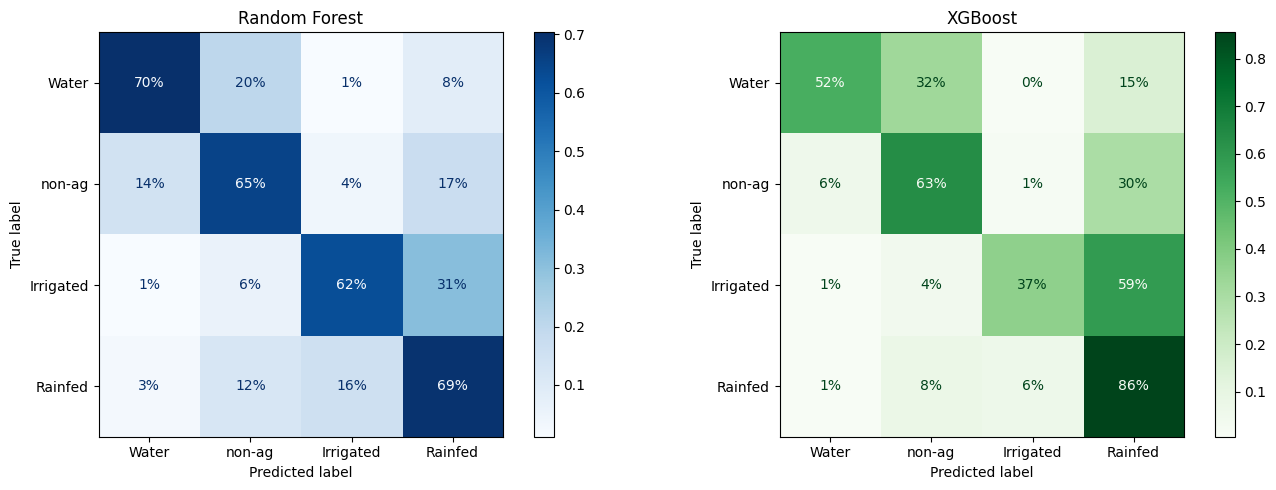

In [11]:
# %% Comparison Table
print("\n" + "="*50)
print("COMPARISON")
print("="*50)
print(f"{'Metric':<15} {'RF':>10} {'XGBoost':>10}")
print("-"*35)
print(f"{'Accuracy':<15} {accuracy_score(y_val, y_pred_rf):>10.4f} {accuracy_score(y_val, y_pred_xgb):>10.4f}")
print(f"{'Mean Jaccard':<15} {jaccard_score(y_val, y_pred_rf, average='macro'):>10.4f} {jaccard_score(y_val, y_pred_xgb, average='macro'):>10.4f}")
print(f"{'Mean F1':<15} {f1_score(y_val, y_pred_rf, average='macro'):>10.4f} {f1_score(y_val, y_pred_xgb, average='macro'):>10.4f}")

# Per-class
print("\nPer-class Jaccard:")
rf_jac = jaccard_score(y_val, y_pred_rf, average=None)
xgb_jac = jaccard_score(y_val, y_pred_xgb, average=None)
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:<10} {rf_jac[i]:>10.4f} {xgb_jac[i]:>10.4f}")

# %% Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred_rf,normalize='true'), display_labels=CLASS_NAMES).plot(ax=axes[0], cmap='Blues', values_format='.0%')
axes[0].set_title('Random Forest')

ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred_xgb,normalize='true'), display_labels=CLASS_NAMES).plot(ax=axes[1], cmap='Greens', values_format='.0%')
axes[1].set_title('XGBoost')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrices.png'), dpi=300)
plt.show()

[Parallel(n_jobs=46)]: Using backend ThreadingBackend with 46 concurrent workers.
[Parallel(n_jobs=46)]: Done 108 tasks      | elapsed:    0.1s
[Parallel(n_jobs=46)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=46)]: Using backend ThreadingBackend with 46 concurrent workers.
[Parallel(n_jobs=46)]: Done 108 tasks      | elapsed:    0.1s
[Parallel(n_jobs=46)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=46)]: Using backend ThreadingBackend with 46 concurrent workers.
[Parallel(n_jobs=46)]: Done 108 tasks      | elapsed:    0.1s
[Parallel(n_jobs=46)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=46)]: Using backend ThreadingBackend with 46 concurrent workers.
[Parallel(n_jobs=46)]: Done 108 tasks      | elapsed:    0.1s
[Parallel(n_jobs=46)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=46)]: Using backend ThreadingBackend with 46 concurrent workers.
[Parallel(n_jobs=46)]: Done 108 tasks      | elapsed:    0

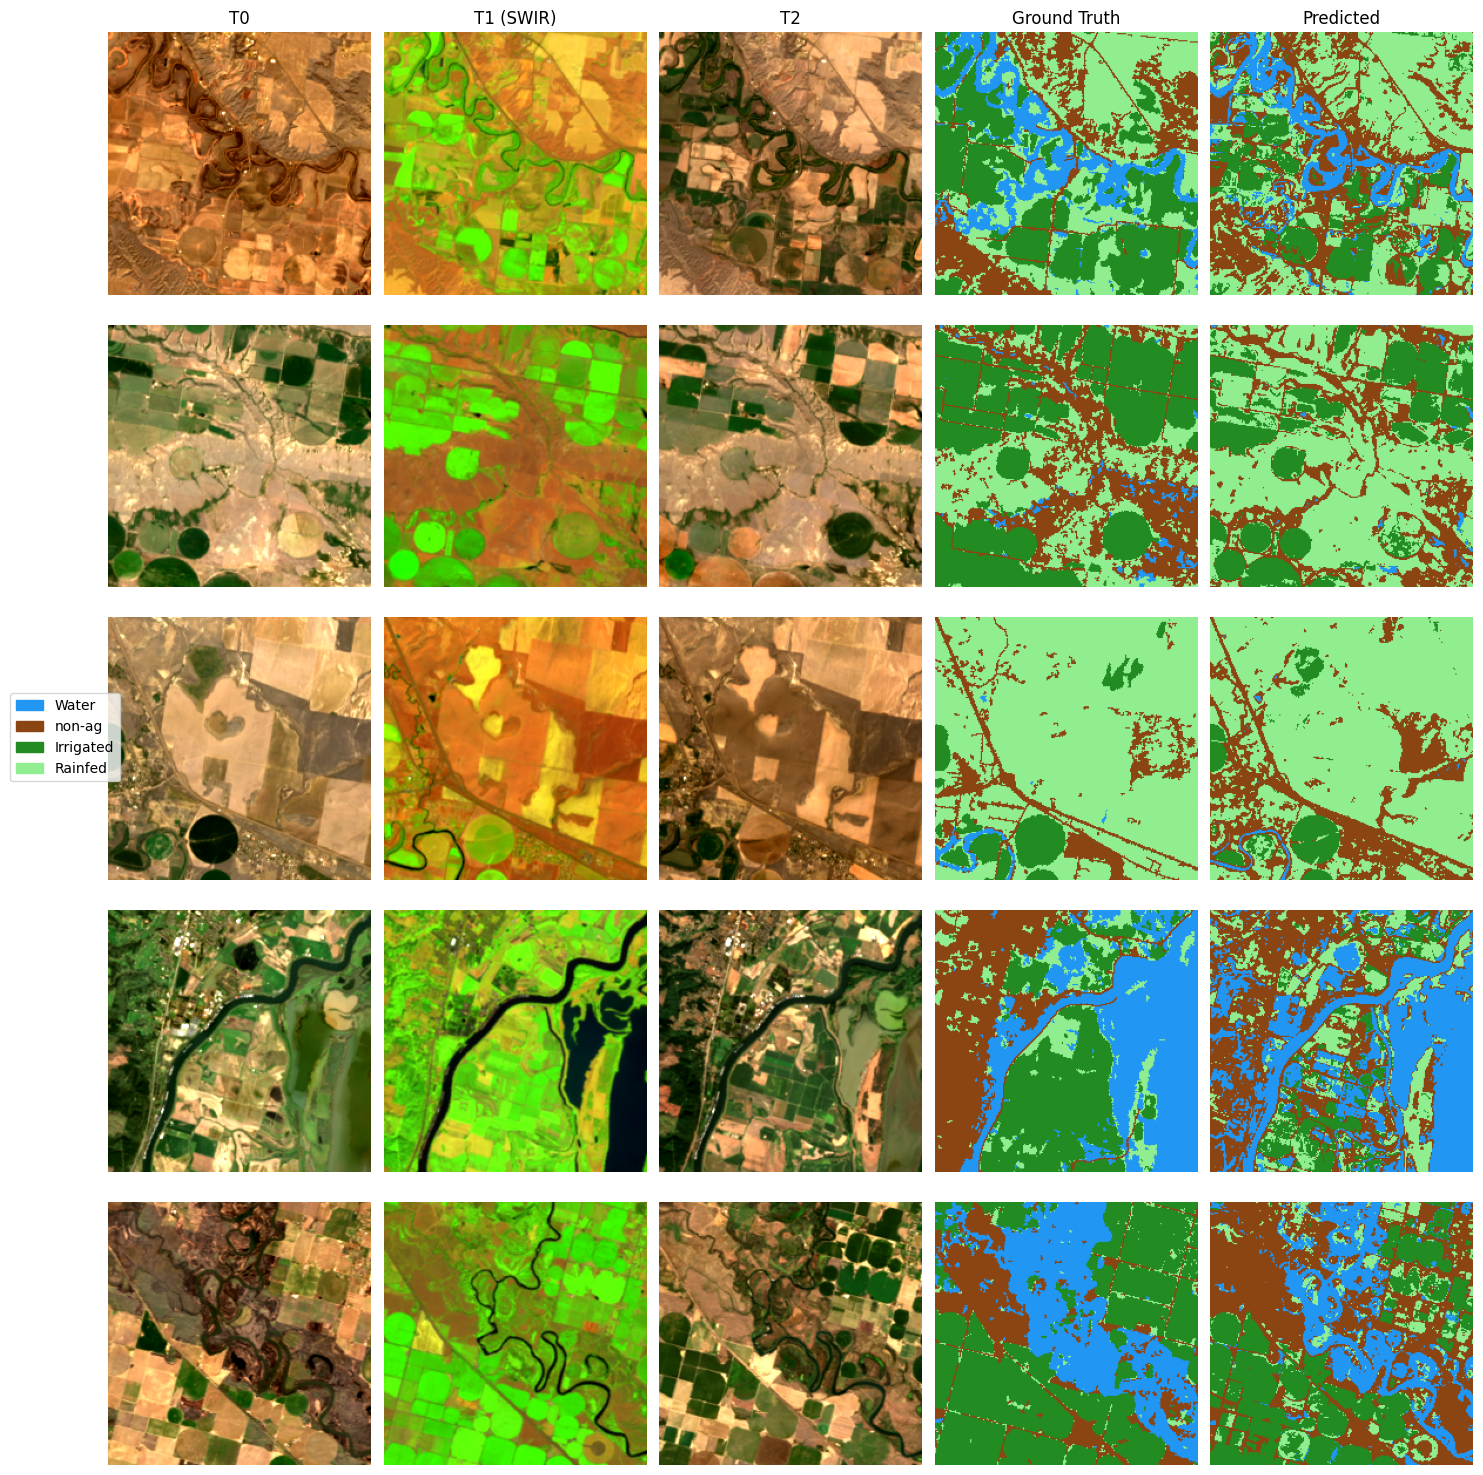

In [26]:
# %% Visualize predictions for sample chips
import matplotlib.patches as mpatches

n_chips = 5
np.random.seed(42)
# sample_indices = np.random.choice(len(val_images), n_chips, replace=False)
sample_indices = range(10,15)
fig, axes = plt.subplots(n_chips, 5, figsize=(15, 3*n_chips))

colors = ['#2196F3', '#8B4513', '#228B22', '#90EE90']
cmap = plt.cm.colors.ListedColormap(colors)

def norm(arr):
    p2, p98 = np.percentile(arr, (2, 98))
    return np.clip((arr - p2) / (p98 - p2 + 1e-6), 0, 1)

for row, idx in enumerate(sample_indices):
    img_path = val_images[idx]
    mask_path = img_path.replace('_merged.tif', '.mask.tif')
    
    with rasterio.open(img_path) as src:
        img = src.read()
    with rasterio.open(mask_path) as src:
        mask = src.read(1)
    
    H, W = mask.shape
    
    t0 = norm(np.moveaxis(img[2::-1], 0, -1))              # RGB
    t1 = norm(np.moveaxis(img[[10, 9, 6]], 0, -1))         # SWIR1, NIR, GREEN
    t2 = norm(np.moveaxis(img[14:11:-1], 0, -1))           # RGB
    
    X = img.reshape(18, -1).T
    pred = rf.predict(X).reshape(H, W)
    
    axes[row, 0].imshow(t0)
    axes[row, 1].imshow(t1)
    axes[row, 2].imshow(t2)
    axes[row, 3].imshow(mask, cmap=cmap, vmin=0, vmax=3)
    axes[row, 4].imshow(pred, cmap=cmap, vmin=0, vmax=3)
    
    for ax in axes[row]:
        ax.axis('off')

axes[0, 0].set_title('T0')
axes[0, 1].set_title('T1 (SWIR)')
axes[0, 2].set_title('T2')
axes[0, 3].set_title('Ground Truth')
axes[0, 4].set_title('Predicted')

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, CLASS_NAMES)]
fig.legend(handles=patches, loc='center left', bbox_to_anchor=(0.01, 0.5))

plt.tight_layout()
plt.subplots_adjust(left=0.08)
plt.savefig(os.path.join(OUTPUT_DIR, 'prediction_samples.png'), dpi=300, bbox_inches='tight')
plt.show()